In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from datetime import datetime, timedelta
import pandas as pd
import h5py

In [12]:
file = "/datasets/FourCastNet/FCN_ERA5_data_v0/precip/train/1984.h5"

In [13]:
with h5py.File(file, 'r') as hdf:
	keys = list(hdf.keys())
	print("Keys:", keys)
	for key in keys:
		data_shape = hdf[key].shape
		print(f"data for key '{key}' has shape {data_shape}")
	


Keys: ['tp']
data for key 'tp' has shape (1464, 720, 1440)


In [10]:
with h5py.File(file, 'r') as hdf:
	keys = list(hdf.keys())
	print("Keys:", keys)
	for key in keys:
		data = hdf[key][:1]

Keys: ['tp']


In [11]:
fields = data

In [12]:
time = np.arange(0, 1460, 1)

In [13]:
long = np.arange(-180, 180, 0.25)
lat = np.arange(-90, 90, 0.25)

In [14]:
X,Y = np.meshgrid(long, lat)


In [15]:
nan_count = np.isnan(fields[0,:,:]).sum().item()
nan_count

0

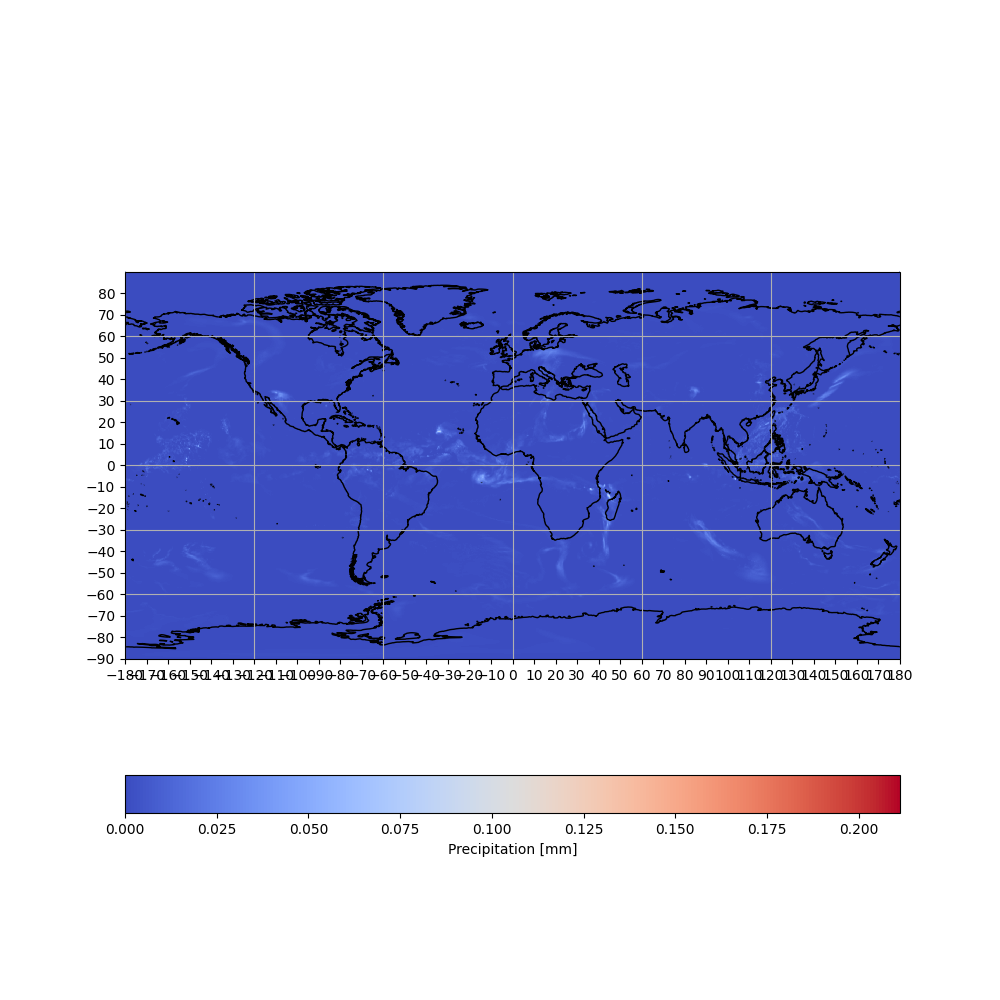

In [16]:
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(resolution="50m")
ax.set_xticks(range(-180, 181, 10), crs=ccrs.PlateCarree())
ax.set_yticks(range(-90, 91, 10), crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=False)

ax.pcolormesh(X, Y, fields[0, :, :], cmap='coolwarm')

fig.colorbar(ax.pcolormesh(X, Y, fields[0, :, :], cmap='coolwarm'), ax=ax, orientation='horizontal', label='Precipitation [mm]')
